# Weather MLOps — Exploration DuckDB Analytics

Notebook d'exploration de la couche analytique dbt + DuckDB.  
Source : `data/analytics.duckdb` (régénéré par `make analytics-run`).

**Sections :**
1. Connexion et aperçu des schémas
2. Audit qualité (NULLs, volumétrie, plages de dates)
3. Performance modèle — tendances globales et saisonnalité
4. Performance par ville — classement et heatmap
5. MLOps health — complétude quotidienne et décisions monitoring
6. Forecast vs actual — distribution des erreurs
7. Historique des retrains

**Prérequis :**
```bash
pip install duckdb pandas matplotlib seaborn
make analytics-run   # si analytics.duckdb n'existe pas encore
```

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='tab10')

DB_PATH = Path('..') / 'data' / 'analytics.duckdb'
assert DB_PATH.exists(), f"DuckDB not found: {DB_PATH}\nRun: make analytics-run"

db = duckdb.connect(str(DB_PATH), read_only=True)
print(f"Connected to {DB_PATH.resolve()}")

Connected to /mnt/c/Users/Ellie Pro/Documents/Projets Data/projets_github/weather-mlops/data/analytics.duckdb


## 1. Aperçu des schémas

In [2]:
schemas = db.execute("SHOW SCHEMAS").df()
print("Schémas disponibles :")
print(schemas.to_string(index=False))

Schémas disponibles :
database_name       schema_name  current
    analytics              main     True
    analytics         main_core    False
    analytics main_intermediate    False
    analytics        main_marts    False
    analytics      main_staging    False


In [3]:
MARTS = [
    'mart_model_performance_overview',
    'mart_model_performance_by_city',
    'mart_forecast_vs_actual_timeline',
    'mart_mlops_health',
    'mart_retraining_history',
]

print(f"{'Table':<45} {'Lignes':>8}  {'Colonnes':>8}")
print('-' * 65)
for t in MARTS:
    n_rows = db.execute(f"SELECT COUNT(*) FROM main_marts.{t}").fetchone()[0]
    n_cols = db.execute(
        f"SELECT COUNT(*) FROM information_schema.columns "
        f"WHERE table_schema='main_marts' AND table_name='{t}'"
    ).fetchone()[0]
    print(f"  {t:<43} {n_rows:>8,}  {n_cols:>8}")

Table                                           Lignes  Colonnes
-----------------------------------------------------------------
  mart_model_performance_overview                  220         9
  mart_model_performance_by_city                 5,720        11
  mart_forecast_vs_actual_timeline               2,314        23
  mart_mlops_health                                 30        17
  mart_retraining_history                            1        19


## 2. Audit qualité

In [4]:
print("=== NULL rates par colonne (colonnes avec NULLs seulement) ===")
for t in MARTS:
    cols = db.execute(
        f"SELECT column_name FROM information_schema.columns "
        f"WHERE table_schema='main_marts' AND table_name='{t}' ORDER BY ordinal_position"
    ).fetchall()
    total = db.execute(f"SELECT COUNT(*) FROM main_marts.{t}").fetchone()[0]
    null_cols = []
    for (c,) in cols:
        n = db.execute(f'SELECT COUNT(*) FROM main_marts.{t} WHERE "{c}" IS NULL').fetchone()[0]
        if n > 0:
            null_cols.append((c, n, n / total * 100))
    if null_cols:
        print(f"\n[{t}]")
        for c, n, pct in null_cols:
            flag = " ← attendu (LEAD sans suivant)" if t == 'mart_retraining_history' else ""
            print(f"  {c}: {n}/{total} ({pct:.0f}%){flag}")
    else:
        print(f"\n[{t}] ✓ aucun NULL")

=== NULL rates par colonne (colonnes avec NULLs seulement) ===

[mart_model_performance_overview] ✓ aucun NULL

[mart_model_performance_by_city] ✓ aucun NULL

[mart_forecast_vs_actual_timeline] ✓ aucun NULL

[mart_mlops_health]
  monitoring_action: 30/30 (100%)
  monitoring_reason: 30/30 (100%)
  n_drifted_features: 30/30 (100%)
  heavy_drift: 30/30 (100%)
  mild_drift: 30/30 (100%)
  low_accuracy: 30/30 (100%)
  high_mae: 30/30 (100%)
  rain_accuracy_30d: 30/30 (100%)
  temp_mae_30d: 30/30 (100%)
  last_retrain_date: 30/30 (100%)
  days_since_retrain: 30/30 (100%)

[mart_retraining_history]
  next_retrain_date: 1/1 (100%) ← attendu (LEAD sans suivant)
  next_rain_accuracy: 1/1 (100%) ← attendu (LEAD sans suivant)
  next_temp_mae: 1/1 (100%) ← attendu (LEAD sans suivant)
  accuracy_delta: 1/1 (100%) ← attendu (LEAD sans suivant)
  mae_delta: 1/1 (100%) ← attendu (LEAD sans suivant)


In [5]:
print("=== Plages de dates par mart ===")
date_cols = {
    'mart_model_performance_overview': 'month',
    'mart_model_performance_by_city': 'month',
    'mart_forecast_vs_actual_timeline': 'prediction_date',
    'mart_mlops_health': 'date',
    'mart_retraining_history': 'retrain_date',
}
for t, col in date_cols.items():
    r = db.execute(f"SELECT MIN({col}), MAX({col}) FROM main_marts.{t}").fetchone()
    print(f"  {t}: {r[0]} → {r[1]}")

=== Plages de dates par mart ===
  mart_model_performance_overview: 2008-01-01 00:00:00 → 2026-04-01 00:00:00
  mart_model_performance_by_city: 2008-01-01 00:00:00 → 2026-04-01 00:00:00
  mart_forecast_vs_actual_timeline: 2026-01-29 → 2026-04-27
  mart_mlops_health: 2026-03-30 → 2026-04-28
  mart_retraining_history: 2026-04-29 → 2026-04-29


In [6]:
print("=== Types de colonnes (dates) ===")
for t, col in date_cols.items():
    dtype = db.execute(
        f"SELECT data_type FROM information_schema.columns "
        f"WHERE table_schema='main_marts' AND table_name='{t}' AND column_name='{col}'"
    ).fetchone()
    expected = 'DATE'
    flag = '✓' if dtype and 'DATE' in dtype[0] else '✗ TIMESTAMP'
    print(f"  {t}.{col}: {dtype[0] if dtype else 'n/a'} {flag}")

=== Types de colonnes (dates) ===
  mart_model_performance_overview.month: TIMESTAMP ✗ TIMESTAMP
  mart_model_performance_by_city.month: TIMESTAMP ✗ TIMESTAMP
  mart_forecast_vs_actual_timeline.prediction_date: DATE ✓
  mart_mlops_health.date: DATE ✓
  mart_retraining_history.retrain_date: DATE ✓


## 3. Performance modèle — tendances globales

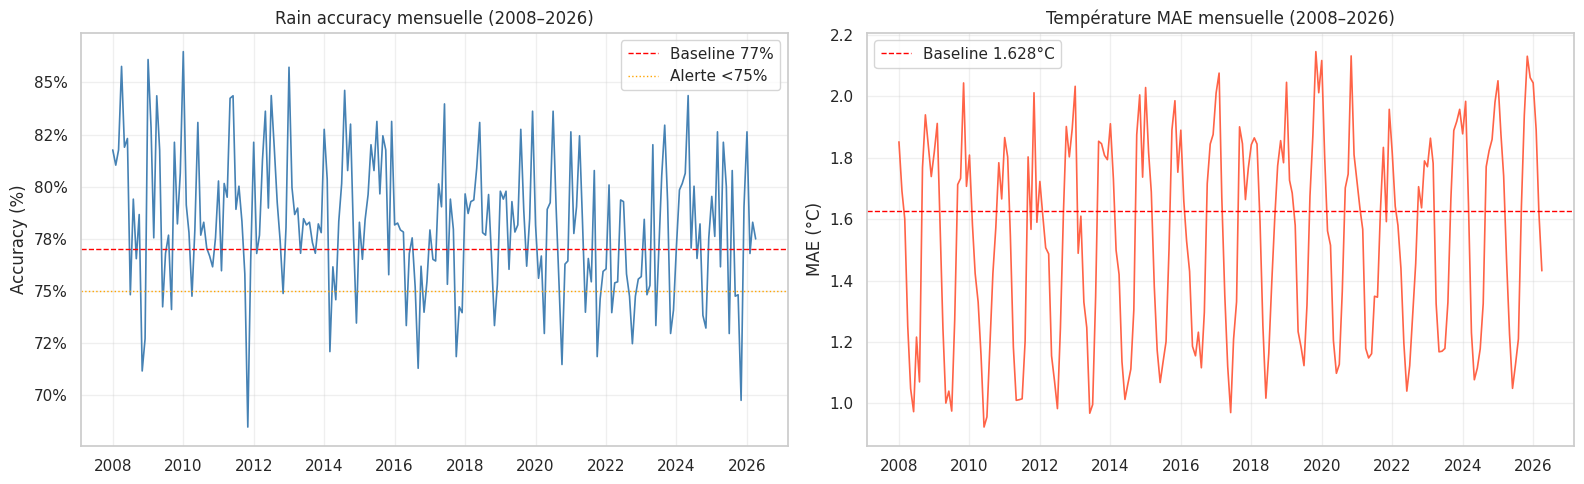

Rain accuracy : min=0.685  max=0.865  moy=0.782
Temp MAE      : min=0.923°C  max=2.146°C  moy=1.537°C


In [7]:
perf = db.execute("""
    SELECT month, rain_accuracy, temp_mae, n_city_days
    FROM main_marts.mart_model_performance_overview
    ORDER BY month
""").df()
perf['month'] = pd.to_datetime(perf['month'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rain accuracy
axes[0].plot(perf['month'], perf['rain_accuracy'] * 100, color='steelblue', linewidth=1.2)
axes[0].axhline(77.0, color='red', linestyle='--', linewidth=1, label='Baseline 77%')
axes[0].axhline(75.0, color='orange', linestyle=':', linewidth=1, label='Alerte <75%')
axes[0].set_title('Rain accuracy mensuelle (2008–2026)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
axes[0].legend()

# Temp MAE
axes[1].plot(perf['month'], perf['temp_mae'], color='tomato', linewidth=1.2)
axes[1].axhline(1.628, color='red', linestyle='--', linewidth=1, label='Baseline 1.628°C')
axes[1].set_title('Température MAE mensuelle (2008–2026)')
axes[1].set_ylabel('MAE (°C)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Rain accuracy : min={perf['rain_accuracy'].min():.3f}  max={perf['rain_accuracy'].max():.3f}  moy={perf['rain_accuracy'].mean():.3f}")
print(f"Temp MAE      : min={perf['temp_mae'].min():.3f}°C  max={perf['temp_mae'].max():.3f}°C  moy={perf['temp_mae'].mean():.3f}°C")

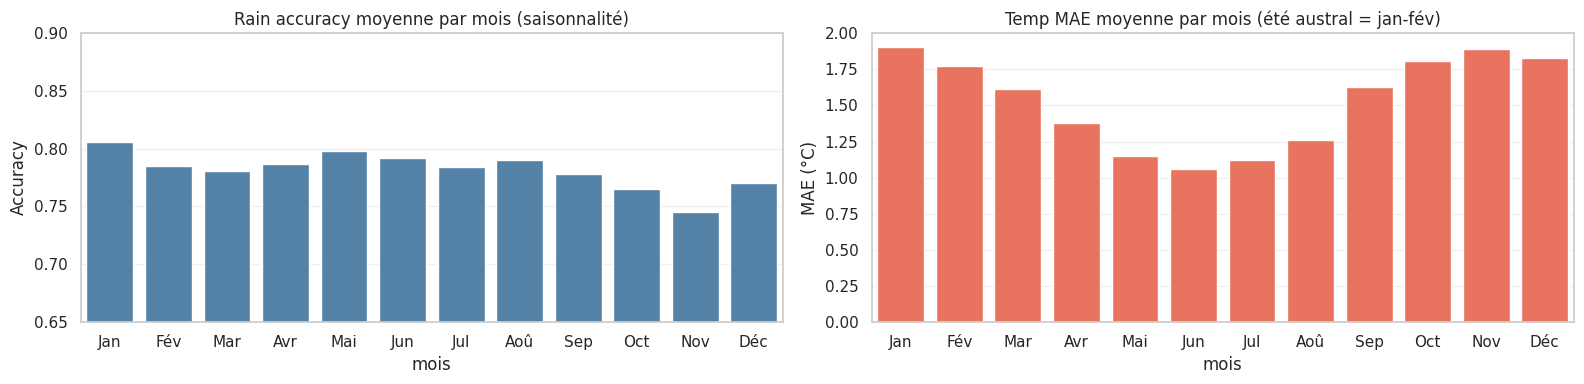

In [8]:
# Saisonnalité — mois calendaire (hémisphère sud : été = jan-fév)
perf['mois_num'] = perf['month'].dt.month
seasonal = perf.groupby('mois_num').agg(
    rain_accuracy=('rain_accuracy', 'mean'),
    temp_mae=('temp_mae', 'mean')
).reset_index()
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
seasonal['mois'] = seasonal['mois_num'].apply(lambda x: mois_labels[x-1])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=seasonal, x='mois', y='rain_accuracy', ax=axes[0], color='steelblue')
axes[0].set_title('Rain accuracy moyenne par mois (saisonnalité)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.65, 0.90)

sns.barplot(data=seasonal, x='mois', y='temp_mae', ax=axes[1], color='tomato')
axes[1].set_title('Temp MAE moyenne par mois (été austral = jan-fév)')
axes[1].set_ylabel('MAE (°C)')

plt.tight_layout()
plt.show()

## 4. Performance par ville

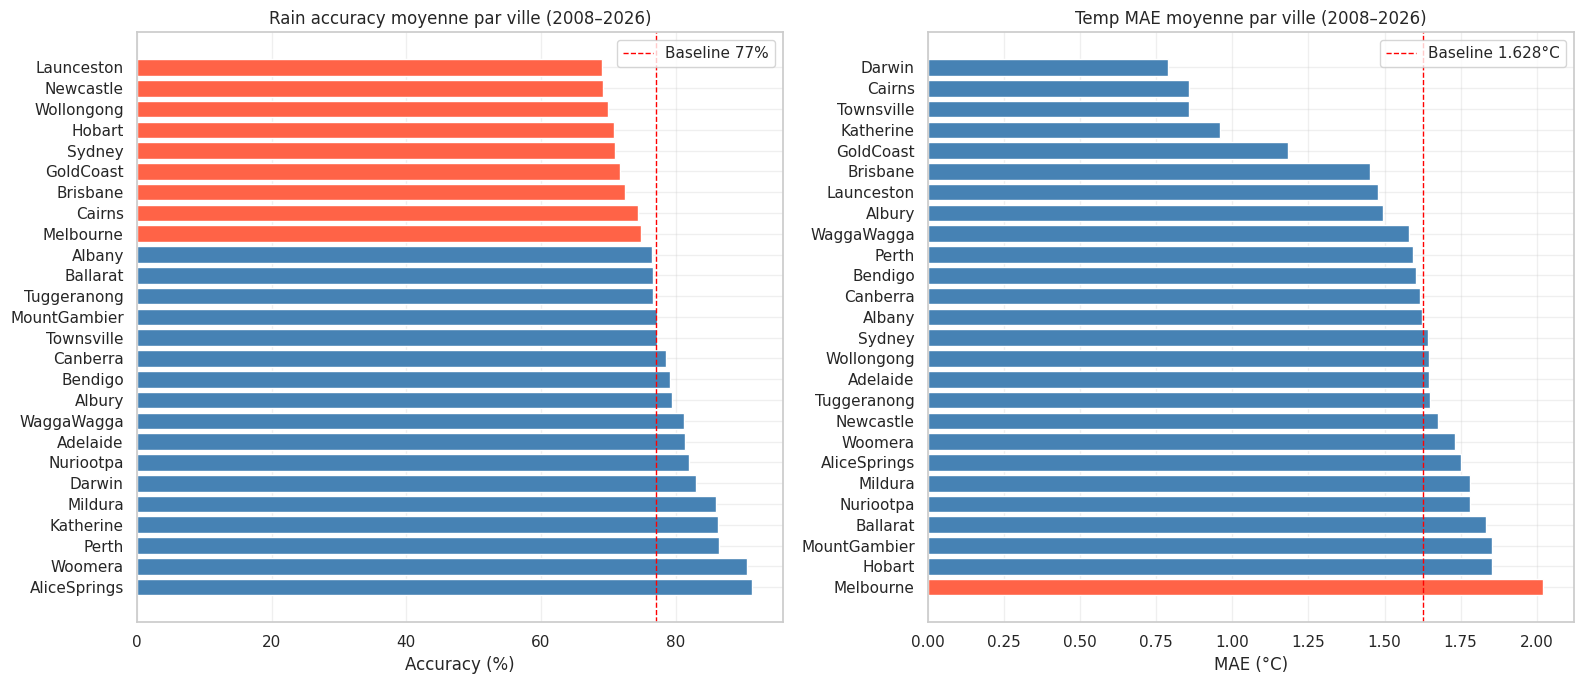


Top 5 meilleures villes (rain accuracy) :
        city state  rain_accuracy_avg
AliceSprings    NT              0.914
     Woomera    SA              0.906
       Perth    WA              0.864
   Katherine    NT              0.862
     Mildura   VIC              0.860

Top 5 villes avec MAE le plus élevé :
        city state  temp_mae_avg
   Melbourne   VIC         2.021
      Hobart   TAS         1.855
MountGambier    SA         1.852
    Ballarat   VIC         1.834
   Nuriootpa    SA         1.782


In [9]:
city_perf = db.execute("""
    SELECT city, state,
           AVG(rain_accuracy) AS rain_accuracy_avg,
           AVG(temp_mae)      AS temp_mae_avg,
           COUNT(*)           AS n_months
    FROM main_marts.mart_model_performance_by_city
    GROUP BY city, state
    ORDER BY rain_accuracy_avg DESC
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Rain accuracy par ville
colors_acc = ['tomato' if v < 0.75 else 'steelblue' for v in city_perf['rain_accuracy_avg']]
axes[0].barh(city_perf['city'], city_perf['rain_accuracy_avg'] * 100, color=colors_acc)
axes[0].axvline(77.0, color='red', linestyle='--', linewidth=1, label='Baseline 77%')
axes[0].set_title('Rain accuracy moyenne par ville (2008–2026)')
axes[0].set_xlabel('Accuracy (%)')
axes[0].legend()

# Temp MAE par ville
city_mae = city_perf.sort_values('temp_mae_avg', ascending=False)
colors_mae = ['tomato' if v > 2.0 else 'steelblue' for v in city_mae['temp_mae_avg']]
axes[1].barh(city_mae['city'], city_mae['temp_mae_avg'], color=colors_mae)
axes[1].axvline(1.628, color='red', linestyle='--', linewidth=1, label='Baseline 1.628°C')
axes[1].set_title('Temp MAE moyenne par ville (2008–2026)')
axes[1].set_xlabel('MAE (°C)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nTop 5 meilleures villes (rain accuracy) :")
print(city_perf[['city','state','rain_accuracy_avg']].head(5).to_string(index=False))
print("\nTop 5 villes avec MAE le plus élevé :")
print(city_mae[['city','state','temp_mae_avg']].head(5).to_string(index=False))

In [10]:
# Heatmap accuracy par ville × mois (derniers 24 mois)
recent = db.execute("""
    SELECT city, month, rain_accuracy
    FROM main_marts.mart_model_performance_by_city
    WHERE month >= dateadd('month', -24, current_date)
    ORDER BY month, city
""").df()
recent['month'] = pd.to_datetime(recent['month']).dt.strftime('%Y-%m')

pivot = recent.pivot(index='city', columns='month', values='rain_accuracy')

fig, ax = plt.subplots(figsize=(18, 9))
sns.heatmap(
    pivot, ax=ax, cmap='RdYlGn', vmin=0.60, vmax=0.90,
    linewidths=0.3, annot=False, fmt='.2f',
    cbar_kws={'label': 'Rain accuracy'}
)
ax.set_title('Rain accuracy par ville × mois (24 derniers mois) — rouge < 0.65, vert > 0.85')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

CatalogException: Catalog Error: Scalar Function with name dateadd does not exist!
Did you mean "date_add"?

LINE 4:     WHERE month >= dateadd('month', -24, current_date)
                           ^

## 5. MLOps health — complétude et monitoring

In [ ]:
health = db.execute("""
    SELECT date, completeness_pct, missing_city_count, has_gap,
           monitoring_action, n_drifted_features, heavy_drift,
           rain_accuracy_30d, temp_mae_30d, days_since_retrain
    FROM main_marts.mart_mlops_health
    ORDER BY date
""").df()
health['date'] = pd.to_datetime(health['date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Complétude
axes[0].fill_between(health['date'], health['completeness_pct'], alpha=0.4, color='steelblue')
axes[0].plot(health['date'], health['completeness_pct'], color='steelblue', linewidth=1.5)
axes[0].set_ylim(80, 102)
axes[0].axhline(100, color='green', linestyle='--', linewidth=0.8, label='100% (26/26 villes)')
axes[0].set_ylabel('Complétude (%)')
axes[0].set_title('Complétude des données — 30 derniers jours')
axes[0].legend()

# Monitoring metrics
has_metrics = health['rain_accuracy_30d'].notna()
if has_metrics.any():
    axes[1].plot(health.loc[has_metrics, 'date'], health.loc[has_metrics, 'rain_accuracy_30d'] * 100,
                 label='Rain accuracy 30j', color='steelblue')
    ax2 = axes[1].twinx()
    ax2.plot(health.loc[has_metrics, 'date'], health.loc[has_metrics, 'temp_mae_30d'],
             label='Temp MAE 30j', color='tomato', linestyle='--')
    ax2.set_ylabel('MAE (°C)', color='tomato')
    axes[1].set_ylabel('Rain accuracy (%)')
    axes[1].legend(loc='upper left')
    ax2.legend(loc='upper right')
else:
    axes[1].text(0.5, 0.5, 'Métriques monitoring pas encore disponibles\n(run le monitoring DAG pour peupler ces données)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12, color='gray')
axes[1].set_title('Métriques de monitoring (30j glissants)')

plt.tight_layout()
plt.show()

print(f"\nComplétude : min={health['completeness_pct'].min():.1f}%  moy={health['completeness_pct'].mean():.1f}%")
print(f"Jours avec gap : {health['has_gap'].sum()}")
print(f"Décisions monitoring : {health['monitoring_action'].value_counts().to_dict()}")

## 6. Forecast vs actual — distribution des erreurs

In [ ]:
fva = db.execute("""
    SELECT prediction_date, city, state,
           pred_rain_tomorrow, actual_rain, rain_correct,
           pred_max_temp_tomorrow, actual_max_temp, temp_abs_error,
           has_actuals, rain_accuracy_30d, temp_mae_30d
    FROM main_marts.mart_forecast_vs_actual_timeline
    WHERE has_actuals
    ORDER BY prediction_date, city
""").df()
fva['prediction_date'] = pd.to_datetime(fva['prediction_date'])

print(f"Lignes avec actuals : {len(fva):,} / {len(fva):,}")
print(f"Rain accuracy globale : {fva['rain_correct'].mean():.3f}")
print(f"Temp MAE global      : {fva['temp_abs_error'].mean():.3f}°C")
print(f"Période              : {fva['prediction_date'].min().date()} → {fva['prediction_date'].max().date()}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution des erreurs de température
axes[0].hist(fva['temp_abs_error'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(fva['temp_abs_error'].mean(), color='red', linestyle='--',
                label=f"Moyenne {fva['temp_abs_error'].mean():.2f}°C")
axes[0].axvline(fva['temp_abs_error'].median(), color='orange', linestyle=':',
                label=f"Médiane {fva['temp_abs_error'].median():.2f}°C")
axes[0].set_title('Distribution des erreurs de température (|prédit - réel|)')
axes[0].set_xlabel('Erreur absolue (°C)')
axes[0].legend()

# Confusion matrix pluie
tp = ((fva['pred_rain_tomorrow'] == True)  & (fva['actual_rain'] == True)).sum()
tn = ((fva['pred_rain_tomorrow'] == False) & (fva['actual_rain'] == False)).sum()
fp = ((fva['pred_rain_tomorrow'] == True)  & (fva['actual_rain'] == False)).sum()
fn = ((fva['pred_rain_tomorrow'] == False) & (fva['actual_rain'] == True)).sum()
cm = pd.DataFrame([[tp, fn], [fp, tn]],
                  index=['Prédit Pluie', 'Prédit Pas Pluie'],
                  columns=['Réel Pluie', 'Réel Pas Pluie'])
sns.heatmap(cm, ax=axes[1], annot=True, fmt='d', cmap='Blues',
            linewidths=1, cbar=False)
axes[1].set_title(f'Matrice de confusion — Pluie demain\n(accuracy={fva["rain_correct"].mean():.3f})')

plt.tight_layout()
plt.show()

In [ ]:
# Erreurs de température par ville (90 derniers jours)
city_errors = (
    fva.groupby('city')['temp_abs_error']
    .agg(['mean', 'median', 'max'])
    .round(2)
    .rename(columns={'mean': 'MAE', 'median': 'Médiane', 'max': 'Max'})
    .sort_values('MAE', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 7))
city_errors['MAE'].plot(kind='barh', ax=ax, color='steelblue', alpha=0.8, label='MAE')
ax.axvline(fva['temp_abs_error'].mean(), color='red', linestyle='--',
           label=f'Moyenne globale {fva["temp_abs_error"].mean():.2f}°C')
ax.set_title('MAE température par ville (90 derniers jours)')
ax.set_xlabel('MAE (°C)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nVilles avec MAE > 2°C :")
print(city_errors[city_errors['MAE'] > 2.0].to_string())

In [ ]:
# Rolling accuracy 30j par ville — dernières semaines
last_date = fva['prediction_date'].max()
recent_rolling = fva[fva['prediction_date'] == last_date][['city', 'state', 'rain_accuracy_30d', 'temp_mae_30d']]
recent_rolling = recent_rolling.sort_values('rain_accuracy_30d')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colors_r = ['tomato' if v < 0.70 else ('orange' if v < 0.75 else 'steelblue')
            for v in recent_rolling['rain_accuracy_30d']]
axes[0].barh(recent_rolling['city'], recent_rolling['rain_accuracy_30d'] * 100, color=colors_r)
axes[0].axvline(75, color='orange', linestyle=':', linewidth=1.5, label='Seuil alerte 75%')
axes[0].set_title(f'Rolling accuracy 30j par ville (au {last_date.date()})')
axes[0].set_xlabel('Accuracy (%)')
axes[0].legend()

recent_rolling_mae = recent_rolling.sort_values('temp_mae_30d', ascending=False)
colors_m = ['tomato' if v > 2.5 else 'steelblue' for v in recent_rolling_mae['temp_mae_30d']]
axes[1].barh(recent_rolling_mae['city'], recent_rolling_mae['temp_mae_30d'], color=colors_m)
axes[1].axvline(1.628, color='red', linestyle='--', linewidth=1.5, label='Baseline MAE 1.628°C')
axes[1].set_title(f'Rolling MAE 30j par ville (au {last_date.date()})')
axes[1].set_xlabel('MAE (°C)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Historique des retrains

In [ ]:
retrains = db.execute("""
    SELECT retrain_date, source, trigger_action, trigger_reason,
           n_drifted_features, heavy_drift, preceded_by_gap,
           rain_accuracy_at_retrain, temp_mae_at_retrain,
           accuracy_delta, mae_delta, accuracy_degraded_after_retrain
    FROM main_marts.mart_retraining_history
    ORDER BY retrain_date DESC
""").df()

print(f"Nombre de retrains enregistrés : {len(retrains)}")
print()
print(retrains.T.to_string())

In [ ]:
if len(retrains) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    retrains['retrain_date'] = pd.to_datetime(retrains['retrain_date'])
    has_delta = retrains['accuracy_delta'].notna()

    if has_delta.any():
        r = retrains[has_delta]
        colors = ['tomato' if v > 0 else 'steelblue' for v in r['accuracy_delta']]
        axes[0].bar(r['retrain_date'].dt.strftime('%Y-%m-%d'), r['accuracy_delta'] * 100, color=colors)
        axes[0].axhline(0, color='black', linewidth=0.8)
        axes[0].set_title('Delta accuracy après chaque retrain\n(rouge = dégradation)')
        axes[0].set_ylabel('Delta accuracy (pp)')
        plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

        colors_mae = ['tomato' if v > 0 else 'steelblue' for v in r['mae_delta']]
        axes[1].bar(r['retrain_date'].dt.strftime('%Y-%m-%d'), r['mae_delta'], color=colors_mae)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_title('Delta MAE après chaque retrain\n(rouge = dégradation)')
        axes[1].set_ylabel('Delta MAE (°C)')
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

        plt.tight_layout()
        plt.show()
    else:
        print("Pas assez de retrains pour calculer les deltas (LEAD() NULL).")
else:
    print("Un seul retrain enregistré — les deltas seront disponibles après le second retrain.")
    if len(retrains) == 1:
        r = retrains.iloc[0]
        print(f"\nDernier retrain : {r['retrain_date']}")
        print(f"  Source        : {r['source']}")
        print(f"  Déclencheur   : {r['trigger_action']} — {r['trigger_reason']}")
        print(f"  Features driftées : {r['n_drifted_features']}")
        print(f"  Précédé d'un gap  : {r['preceded_by_gap']}")
        print(f"  Rain acc à J0  : {r['rain_accuracy_at_retrain']:.3f}" if pd.notna(r['rain_accuracy_at_retrain']) else "  Rain acc : N/A")
        print(f"  Temp MAE à J0  : {r['temp_mae_at_retrain']:.3f}°C" if pd.notna(r['temp_mae_at_retrain']) else "  Temp MAE : N/A")

## Synthèse

In [ ]:
print("=" * 60)
print("SYNTHÈSE QUALITÉ DES DONNÉES")
print("=" * 60)

# Couverture globale
perf_all = db.execute("SELECT AVG(rain_accuracy), AVG(temp_mae) FROM main_marts.mart_model_performance_overview").fetchone()
print(f"\nPerformance globale (2008–2026) :")
print(f"  Rain accuracy : {perf_all[0]:.3f}  (baseline metrics.json : 0.770)")
print(f"  Temp MAE      : {perf_all[1]:.3f}°C (baseline metrics.json : 1.628°C)")

# Complétude
health_stats = db.execute("SELECT AVG(completeness_pct), MIN(completeness_pct), SUM(CAST(has_gap AS INTEGER)) FROM main_marts.mart_mlops_health").fetchone()
print(f"\nComplétude (30 derniers jours) :")
print(f"  Moyenne : {health_stats[0]:.1f}%")
print(f"  Minimum : {health_stats[1]:.1f}%")
print(f"  Jours avec gap : {health_stats[2]}")

# Forecast quality
fva_stats = db.execute("SELECT AVG(CAST(rain_correct AS DOUBLE)), AVG(temp_abs_error) FROM main_marts.mart_forecast_vs_actual_timeline WHERE has_actuals").fetchone()
print(f"\nQualité forecast (90 derniers jours) :")
print(f"  Rain accuracy : {fva_stats[0]:.3f}")
print(f"  Temp MAE      : {fva_stats[1]:.3f}°C")

print(f"\nRetrains enregistrés : {len(retrains)}")
print("=" * 60)

db.close()
print("\nConnexion DuckDB fermée.")